# Results Visualizations — GDELT trade-flow benchmark

Reads `results_v2.csv` and produces the five comparisons, each **global** (across models) and **per-model**:
1. Added value of GDELT
2. Fusion techniques (concat / blend / attention)
3. Missing-value handling (drop / median / rf)
4. Risk placement (nodes / edges / both)
5. Event selection (keep-all / top-k), including the node×pair 2×2 for the full edge models

**Metric choice:** we lead with **log-R²** (stable on skewed trade value) and **Spearman ρ** (ranking quality),
since raw R² explodes on the large-value tranches. Each section notes which metric is most informative for that question.
All charts use the `all`-flows tranche unless stated; capped axes hide off-scale blow-ups.

## Setup

In [19]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110; plt.rcParams['axes.grid']=True; plt.rcParams['grid.alpha']=0.3

r = pd.read_csv('results_v2.csv')
r = r.drop_duplicates(['model','fusion','scoring','gdelt','risk_level','agg_mode','missing','tranche'], keep='last')
METRICS = ['log_r2','spearman','r2','rmse','mae','smape']
HIGHER_BETTER = {'log_r2':True,'spearman':True,'r2':True,'rmse':False,'mae':False,'smape':False}

def A(df=r, tranche='all', missing='rf'):
    d = df[df.tranche==tranche]
    if missing is not None and 'missing' in d: d = d[d.missing==missing]
    return d.copy()

def barh(series, title, xlabel, cap_lo=None):
    s = series.dropna().sort_values()
    if cap_lo is not None: s = s.clip(lower=cap_lo)
    if len(s) == 0:                                      # <-- guard
        print(f'(skip: no data for "{title}")'); return
    fig,ax=plt.subplots(figsize=(9,max(2,0.45*len(s))))
    colors=['#2ca02c' if v>=0 else '#d62728' for v in s.values]
    ax.barh(s.index.astype(str), s.values, color=colors)
    ax.axvline(0,color='k',lw=.6); ax.set_xlabel(xlabel); ax.set_title(title)
    for i,v in enumerate(s.values): ax.text(v,i,f' {v:.3f}',va='center',fontsize=8)
    plt.tight_layout(); plt.show()

def grouped_bar(piv, title, ylabel, cap=(-1,1)):
    if piv is None or piv.empty or piv.dropna(how='all').empty:    # <-- guard
        print(f'(skip: no data for "{title}")'); return piv
    ax=piv.plot(kind='bar',figsize=(11,5))
    ax.axhline(0,color='k',lw=.6); ax.set_ylabel(ylabel); ax.set_title(title)
    if cap: ax.set_ylim(*cap)
    plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
    return piv

## 1. Added value of GDELT

**Best metric: log-R²** (does geopolitics improve fit) + **Spearman** (does it improve ranking).
We compare each model's no-GDELT baseline vs its best GDELT variant.


=== GDELT value | r2 (all flows) ===


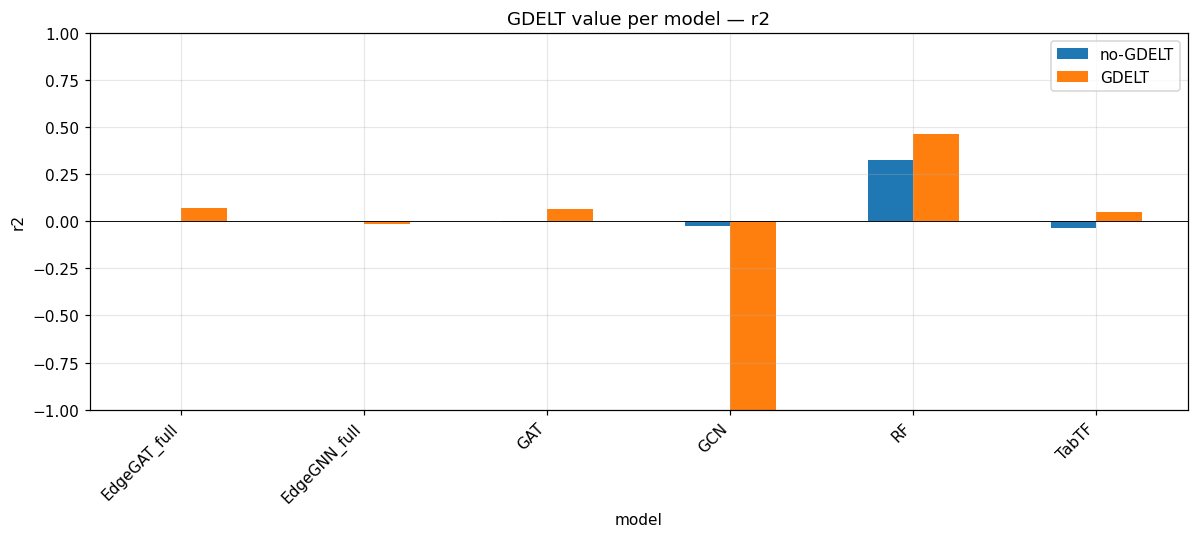

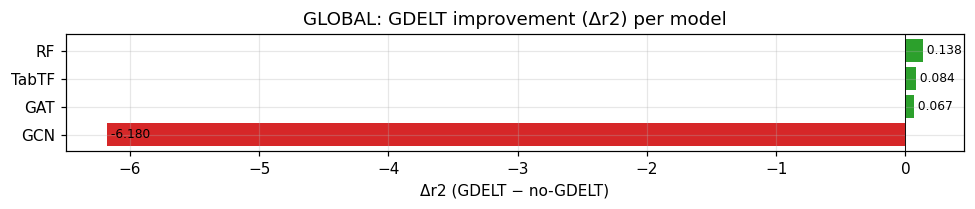


=== GDELT value | log_r2 (all flows) ===


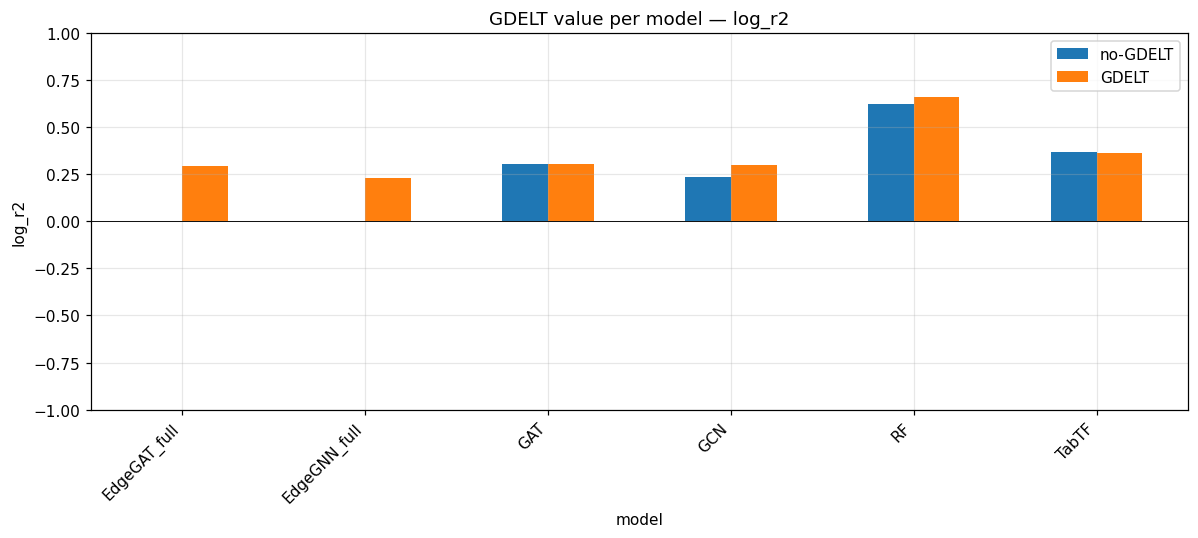

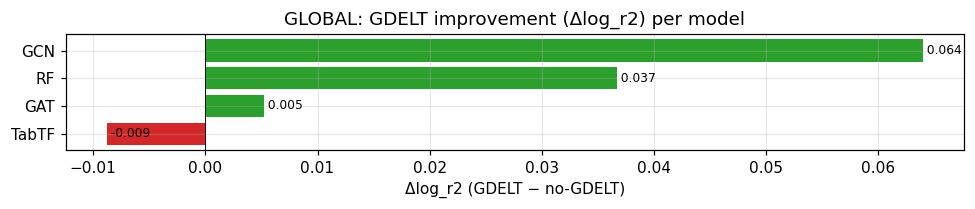


=== GDELT value | spearman (all flows) ===


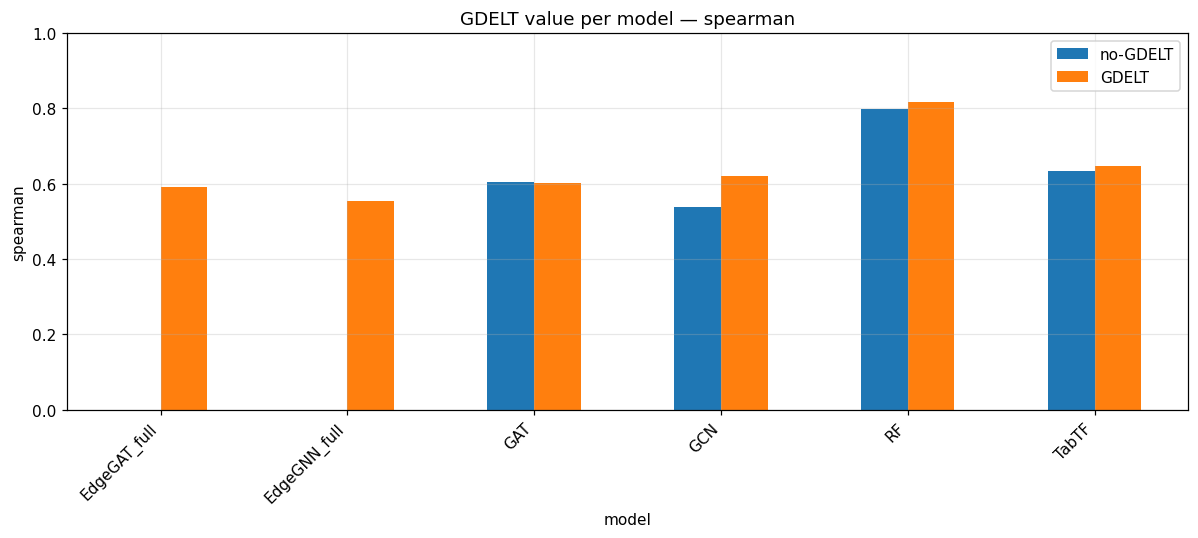

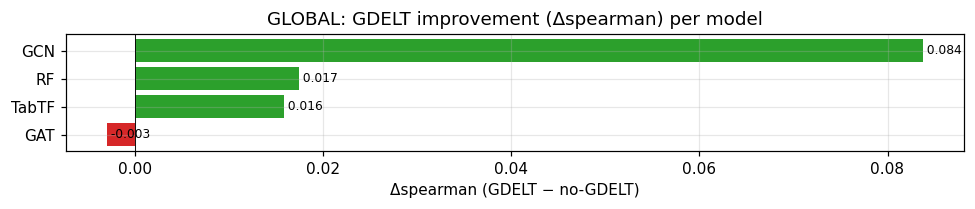

In [20]:
# Added 'r2' to the iteration list
for metric in ['r2', 'log_r2', 'spearman']:
    d = A()

    # per-model: no-GDELT vs GDELT(any)
    base = d[~d.gdelt].groupby('model')[metric].max()
    withg = d[d.gdelt].groupby('model')[metric].max()
    piv = pd.DataFrame({'no-GDELT': base, 'GDELT': withg}).dropna(how='all')

    print(f'\n=== GDELT value | {metric} (all flows) ===')

    # Apply the (-1, 1) cap to both r2 and log_r2 to handle massive negative outliers
    cap_limits = (-1, 1) if metric in ['r2', 'log_r2'] else (0, 1)

    grouped_bar(piv, f'GDELT value per model — {metric}', metric, cap=cap_limits)

    # global: mean delta
    delta = (withg - base).dropna().sort_values()
    barh(delta, f'GLOBAL: GDELT improvement (Δ{metric}) per model', f'Δ{metric} (GDELT − no-GDELT)')

### 1b. Focus: GAT vs EdgeGAT family (node-only vs edge-aware GDELT)

Pulls `GAT` (no-GDELT vs GDELT) next to `EdgeGAT` and `EdgeGAT_full`, since these are structurally
the same attention lineage with progressively more GDELT structure (none/node -> edge -> node+edge).
Edge models only have a GDELT bar (no-GDELT edge model isn't a valid architecture here), so this
shows the node baseline for scale next to them. Two charts: log-R² and Spearman.


=== GAT vs EdgeGAT family | log_r2 (all flows) ===


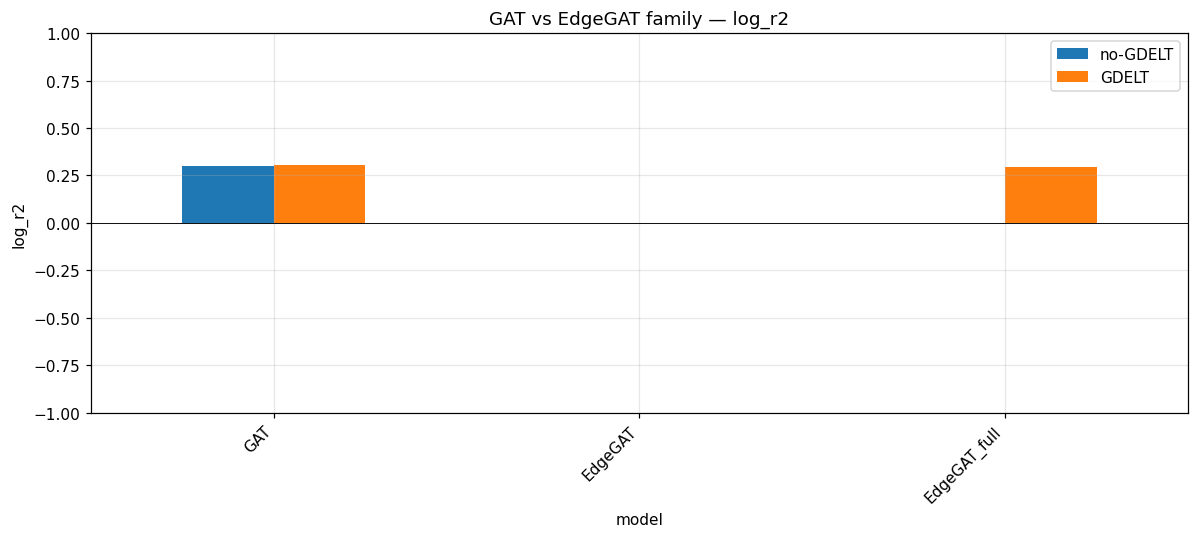


=== GAT vs EdgeGAT family | spearman (all flows) ===


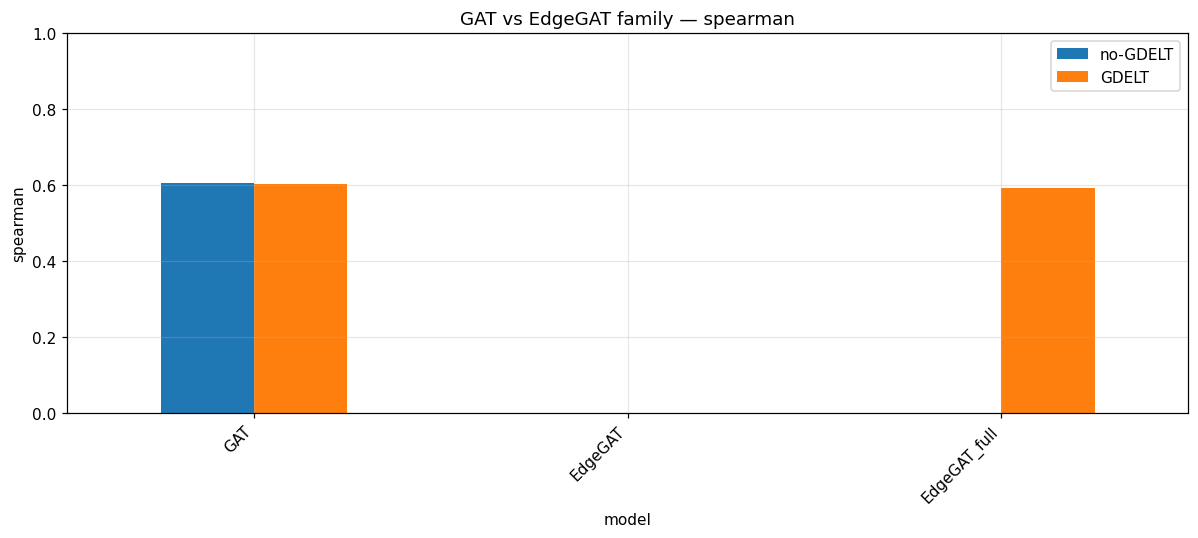

In [21]:
focus_models = ['GAT', 'EdgeGAT', 'EdgeGAT_full']

for metric in ['log_r2', 'spearman']:
    d = A()
    d = d[d.model.isin(focus_models)]

    base  = d[~d.gdelt].groupby('model')[metric].max()
    withg = d[d.gdelt].groupby('model')[metric].max()
    piv = pd.DataFrame({'no-GDELT': base, 'GDELT': withg}).reindex(focus_models)

    print(f'\n=== GAT vs EdgeGAT family | {metric} (all flows) ===')
    cap_limits = (-1, 1) if metric == 'log_r2' else (0, 1)
    grouped_bar(piv, f'GAT vs EdgeGAT family — {metric}', metric, cap=cap_limits)

## 2. Fusion techniques (concat / blend / attention)

**Best metric: log-R².** Fusion applies to node-GAT (Block 2) and now the full edge models.
Global = averaged across the models that have all three fusions; per-model = each separately.

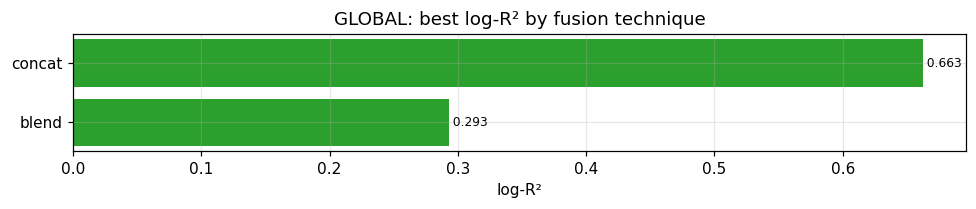

In [22]:
d = A()
fus = d[d.fusion.isin(['concat','blend','attention'])]
# per-model (node GAT + edge models that carry fusion)
for mdl in sorted(fus.model.unique()):
    sub = fus[fus.model==mdl]
    piv = sub.pivot_table(index='fusion', columns='scoring', values='log_r2', aggfunc='max')
    piv = piv.reindex([f for f in ['concat','blend','attention'] if f in piv.index])
    if piv.shape[0] < 2: continue
    print(f'\n--- fusion for {mdl} (log_r2) ---'); print(piv.round(3))
# global: best log_r2 per fusion, across all models
g = fus.groupby('fusion')['log_r2'].max().reindex(['concat','blend','attention'])
barh(g, 'GLOBAL: best log-R² by fusion technique', 'log-R²')

## 3. Missing-value handling (drop / median / rf)

**Best metric: log-R²**, but note **drop** changes the row count (n differs), so compare cautiously.
Global = averaged across models; per-model = each separately. Axis capped to hide any unstable blow-up.

=== missing handling per model (log_r2) ===
missing          rf
model              
EdgeGAT_full  0.293
EdgeGNN_full  0.231
GAT           0.307
GCN           0.302
RF            0.663
TabTF         0.371


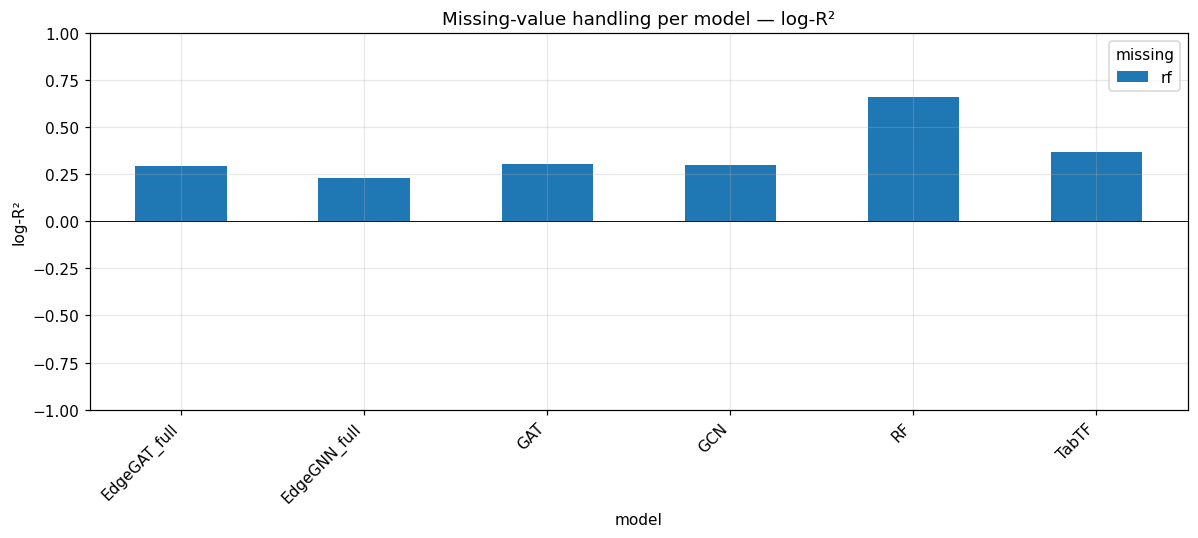

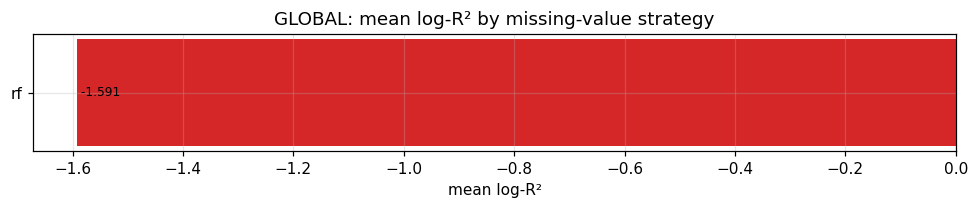

In [23]:
d = r[r.tranche=='all']   # keep all missing strategies
mh = d[d.missing.isin(['drop','median','rf'])]
piv = mh.pivot_table(index='model', columns='missing', values='log_r2', aggfunc='max').dropna(how='all')
print('=== missing handling per model (log_r2) ==='); print(piv.round(3))
grouped_bar(piv, 'Missing-value handling per model — log-R²', 'log-R²', cap=(-1,1))
# global: mean log_r2 per strategy
g = mh.groupby('missing')['log_r2'].mean().sort_values(ascending=False)
barh(g, 'GLOBAL: mean log-R² by missing-value strategy', 'mean log-R²')

## 4. Risk placement — nodes vs edges vs both

**Best metric: log-R²** + **Spearman**. Mapping:
- **node** risk → node-based models (GCN/GAT/GATv2, risk_level=node)
- **edge** risk → thin edge models (EdgeGNN/EdgeGAT, gravity nodes + bilateral edges)
- **both** → full edge models (country-GDELT on nodes + bilateral on edges)

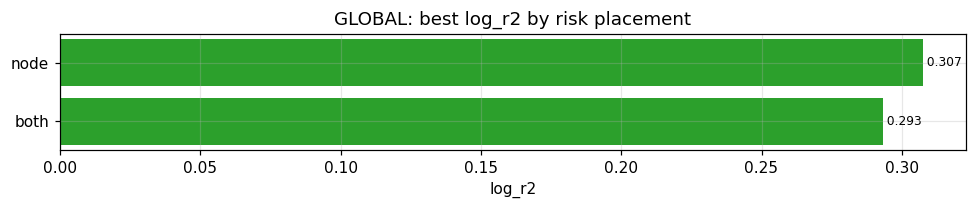

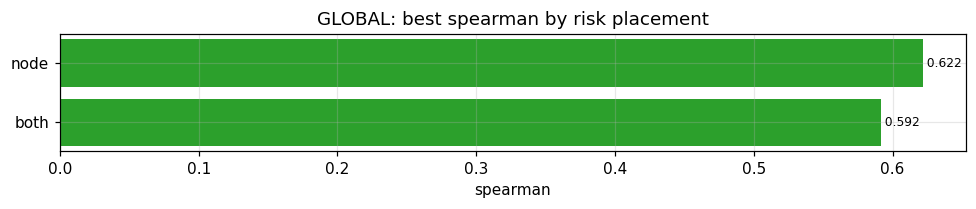

=== per-model log_r2 by placement ===
placement      both   node
model                     
EdgeGAT_full  0.293    NaN
EdgeGNN_full  0.231    NaN
GAT             NaN  0.307
GCN             NaN  0.302


In [24]:
d = A(missing=None)   # edge models logged under bilateral; don't filter missing
def placement(row):
    m=row['model']
    if m in ('GCN','GAT','GATv2') and row['gdelt']: return 'node'
    if m in ('EdgeGNN','EdgeGAT'): return 'edge'
    if m in ('EdgeGNN_full','EdgeGAT_full','EdgeGATv2_full'): return 'both'
    return None
d['placement']=d.apply(placement,axis=1); d=d.dropna(subset=['placement'])
for metric in ['log_r2','spearman']:
    g = d.groupby('placement')[metric].max().reindex(['node','edge','both'])
    barh(g, f'GLOBAL: best {metric} by risk placement', metric)
# per-model detail
piv = d.pivot_table(index='model', columns='placement', values='log_r2', aggfunc='max')
print('=== per-model log_r2 by placement ==='); print(piv.round(3))

## 5. Event selection — keep-all vs top-k

**Best metric: log-R².** For node models: scoring ∈ {keepall, topk}.
For the **full edge models**, selection is 2×2 — node-scorer × pair-scorer:
`ka_ka, ka_tk, tk_ka, tk_tk` (ka=keep-all, tk=top-k). We show that 2×2 heatmap per full-edge model,
and also split by node-fusion (concat vs blend vs attention) since each full-edge model was run under all three.

=== node models: keepall vs topk (log_r2) ===
scoring  keepall   topk
model                  
GAT       -0.515  0.307
GCN        0.302  0.273
RF         0.663  0.612
TabTF      0.140  0.362


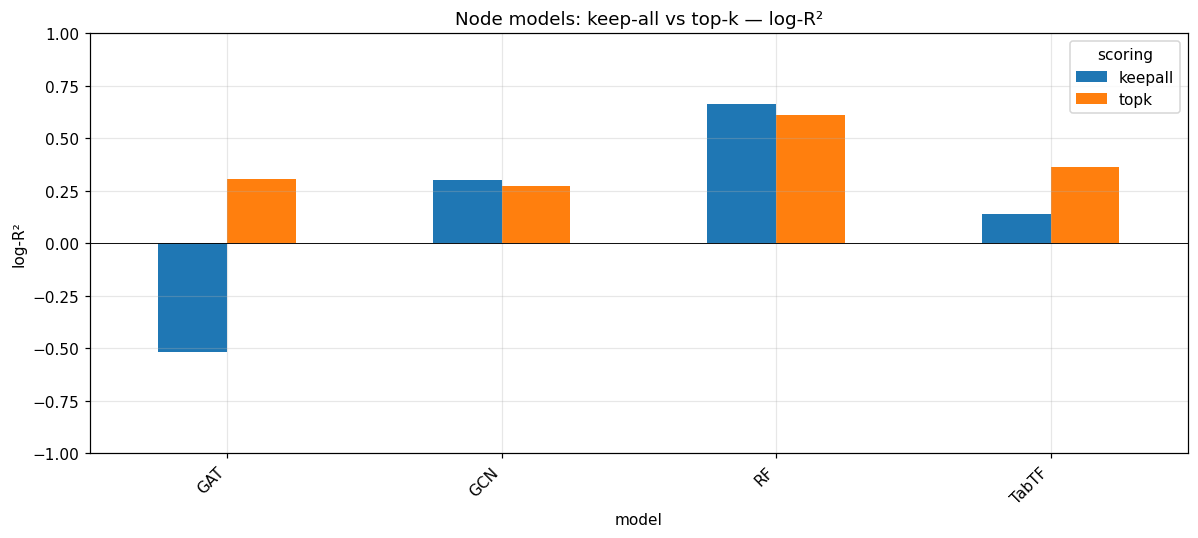


--- EdgeGAT_full | fusion=blend | 2x2 node×pair scorer (log_r2) ---
pair_scorer   pair=keepall  pair=topk
node_scorer                          
node=keepall         0.270      0.245
node=topk            0.293      0.286

--- EdgeGNN_full | fusion=blend | 2x2 node×pair scorer (log_r2) ---
pair_scorer   pair=keepall  pair=topk
node_scorer                          
node=keepall       -12.277    -12.277
node=topk          -12.277      0.231


In [25]:
d = A(missing=None)
# --- node models: simple keepall vs topk ---
nm = d[(d.model.isin(['RF','TabTF','GCN','GAT','GATv2'])) & (d.scoring.isin(['keepall','topk']))]
piv = nm.pivot_table(index='model', columns='scoring', values='log_r2', aggfunc='max')
print('=== node models: keepall vs topk (log_r2) ==='); print(piv.round(3))
grouped_bar(piv, 'Node models: keep-all vs top-k — log-R²', 'log-R²', cap=(-1,1))

# --- full edge models: 2x2 node-scorer x pair-scorer, per fusion ---
fe = d[d.model.str.contains('full')].copy()
combo_split = fe['scoring'].str.split('_', expand=True)
fe['node_scorer']=combo_split[0].map({'ka':'node=keepall','tk':'node=topk'})
fe['pair_scorer']=combo_split[1].map({'ka':'pair=keepall','tk':'pair=topk'})
for mdl in sorted(fe.model.unique()):
    for fusion in sorted(fe[fe.model==mdl].fusion.unique()):
        sub=fe[(fe.model==mdl)&(fe.fusion==fusion)]
        piv=sub.pivot_table(index='node_scorer',columns='pair_scorer',values='log_r2',aggfunc='max')
        if piv.size==0: continue
        print(f'\n--- {mdl} | fusion={fusion} | 2x2 node×pair scorer (log_r2) ---')
        print(piv.round(3))

# Conclusions :